# Sentiment Analysis of Amazon Mobile Reviews Using VADER and LSTM

This notebook compares a lexicon-based approach (VADER) with an LSTM model for sentiment classification on Amazon mobile reviews.

## 1. Environment setup

Importing libraries and downloading the resources required for the analysis.

In [ ]:
!pip install nltk spacy tensorflow scikit-learn
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 47.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from urllib.request import urlretrieve
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import spacy

from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
nltk.download('vader_lexicon')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 2. Loading the dataset

Downloading the dataset and selecting a sample for the analysis.

In [ ]:
amazon_mobile_reviews_url =  "https://eduds.blob.core.windows.net/nlp/Amazon_Unlocked_Mobile.csv.zip"
filename = "Amazon_Unlocked_Mobile.csv.zip"

urlretrieve(amazon_mobile_reviews_url, filename)

with zipfile.ZipFile("/content/Amazon_Unlocked_Mobile.csv.zip") as zfile:
  zfile.extractall()

df = pd.read_csv("/content/Amazon_Unlocked_Mobile.csv")

df = df.sample(50000, random_state=42).reset_index(drop=True)
df.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,Apple iPhone 6 Plus 128GB Factory Unlocked GSM...,NaN,699.95,1,Defective phone. Works only for two days. Phon...,5.0
1,HTC Desire 816 Dual Sim Unlocked Smartphone (W...,HTC,221.00,3,Cool,0.0
2,"BLU Studio 5.0 C HD Unlocked Cellphone, Black",BLU,173.44,5,Beautiful and excellent quality,1.0
3,Apple iPhone 5c 16GB (Pink) - AT&T,Apple,519.00,2,Gave 3 stars because it did not come with a ch...,0.0
4,BLU PURE XL Smartphone - 4G LTE GSM Unlocked -...,BLU,129.99,1,High resolution camera so you can zoom in afte...,1.0


## 3. Baseline sentiment analysis with VADER

Using VADER as a baseline sentiment classifier and evaluating its performance against rating-based labels.

In [ ]:
data = df[['Reviews', 'Rating']].dropna()

def rating(r):
    if r >= 3:
        return 1
    else:
        return 0

data['label'] = data['Rating'].apply(rating)

sid = SentimentIntensityAnalyzer()

def vader(text):
    scores = sid.polarity_scores(str(text))
    comp = scores['compound']
    if comp >= 0.05:
        return 1
    else:
        return 0

data['vader_pred'] = data['Reviews'].apply(vader)

y_true = data['label']
y_pred = data['vader_pred']

print("Accuracy:", accuracy_score(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=['true_neg', 'true_pos'],
    columns=['pred_neg', 'pred_pos']
)
print("Confusion matrix:\n", cm_df)

Accuracy: 0.7912773832149644
Confusion matrix:
           pred_neg  pred_pos
true_neg      8682      3159
true_pos      7274     30870


## 4. Exploratory data analysis and preprocessing

Handling missing values, visualizing the rating distribution, and converting ratings into binary sentiment labels.

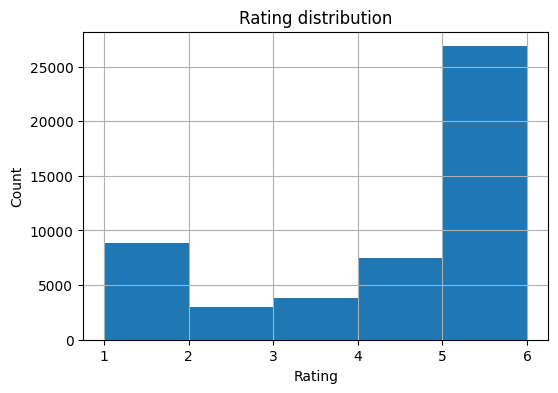

In [ ]:
df['Brand Name'] = df['Brand Name'].fillna("Unknown")

plt.figure(figsize=(6,4))
df['Rating'].hist(bins=[1,2,3,4,5,6])
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Rating distribution')
plt.show()

df['Sentiment'] = df['Rating'].apply(rating)

## 5. Text preprocessing

Lemmatizing the reviews and removing punctuation, stopwords, numbers, and URLs.

In [ ]:
stop_words = set(stopwords.words('english'))

nlp = spacy.load("en_core_web_sm")

def preprocess_text(doc):
    tokens = []
    for token in doc:
        if token.is_punct or token.is_space:
            continue
        if token.like_num or token.like_url:
            continue
        if token.text in stop_words:
            continue
        lemma = token.lemma_.strip()
        if lemma:
            tokens.append(lemma)
    return " ".join(tokens)

texts = df['Reviews'].astype(str).tolist()

cleaned_texts = []

for doc in nlp.pipe(texts, batch_size=500, n_process=2):
  cleaned_texts.append(preprocess_text(doc))

df['Clean_Review'] = cleaned_texts

df[['Reviews', 'Clean_Review']].head(10)

,Reviews,Clean_Review
0,Defective phone. Works only for two days. Phon...,defective phone work day phone flicker screen ...
1,Cool,cool
2,Beautiful and excellent quality,beautiful excellent quality
3,Gave 3 stars because it did not come with a ch...,give star come charger box the battery already...
4,High resolution camera so you can zoom in afte...,high resolution camera zoom picture take print...
5,excelente,excelente
6,"Audio port does not work, brand new phone. The...",audio port work brand new phone then phone sta...
7,Worked fine. Functional like every other bb. N...,worked fine functional like every bb nothing s...
8,Excellent phone. Exceeded my expectations,excellent phone exceed expectation
9,I bought this phone and it worked great the en...,I buy phone work great entire time I own it st...


## 6. Tokenization and padding

Transforming cleaned text into integer sequences and padding them to a fixed length.

In [ ]:
max_words = 50000
tokenizer = Tokenizer(num_words=max_words, oov_token='OOV')

tokenizer.fit_on_texts(df['Clean_Review'])

sequences = tokenizer.texts_to_sequences(df['Clean_Review'])

df['Seq'] = sequences
df[['Clean_Review','Seq']].head(10)

max_len = 50
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

padded_sequences.shape

(50000, 50)

## 7. LSTM model

Building an LSTM-based neural network for binary sentiment classification.

In [ ]:
max_words = 50000
max_len = 50
embedding_dim = 32

model = Sequential()

model.add(Embedding(
    input_dim=max_words,
    output_dim=embedding_dim,
    input_length=max_len
))

model.add(LSTM(30))

model.add(Dense(32, activation='relu'))
model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.build(input_shape=(None, max_len))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 32)         │     1,600,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30)             │         7,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,609,641 (6.14 MB)

 Trainable params: 1,609,641 (6.14 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train-test split and model training

Splitting the data into training and test sets and training the model.

In [ ]:
X = padded_sequences
y = df['Sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=10,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Train: (35000, 50)
Test : (15000, 50)
Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - accuracy: 0.7748 - loss: 0.5260 - val_accuracy: 0.8057 - val_loss: 0.4659
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.8617 - loss: 0.3692 - val_accuracy: 0.8811 - val_loss: 0.3712
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9010 - loss: 0.2727 - val_accuracy: 0.8931 - val_loss: 0.3008
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9233 - loss: 0.2156 - val_accuracy: 0.8983 - val_loss: 0.2779
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.9365 - loss: 0.1823 - val_accuracy: 0.8923 - val_loss: 0.2723
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.9455 - loss: 0.1600 - val_accuracy: 0.8956 - val_loss: 0.2813
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9521 - loss: 0.1436 - val_accuracy: 0.8984 - val_loss: 0.2911


## 9. Model evaluation

Evaluating the LSTM model on the test set using a confusion matrix and accuracy score.

In [ ]:
y_proba = model.predict(X_test)

y_pred = (y_proba >= 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Confusion Matrix:
 [[ 2952   603]
 [ 1030 10415]]
Test Accuracy: 0.8911333333333333


## Conclusion

The baseline VADER approach provides a simple lexicon-based benchmark, while the LSTM model captures more complex patterns in review text.  